In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.svm import SVC
from sklearn.metrics import(accuracy_score,precision_score,classification_report)

In [15]:
df=pd.read_csv("microchip_data.csv",header=None,names=["Voltage_Tolerence","Thermal_Stress","Failure"])
df.head()

,Voltage_Tolerence,Thermal_Stress,Failure
0,0.051267,0.69956,1
1,-0.092742,0.68494,1
2,-0.213710,0.69225,1
3,-0.375000,0.50219,1
4,-0.513250,0.46564,1


In [16]:
X=df[["Voltage_Tolerence","Thermal_Stress"]]
y=df["Failure"]

In [17]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [18]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [19]:
model=SVC(kernel="rbf",C=100,gamma="scale")

In [20]:
model.fit(X_train,y_train)

,C,100
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [13]:
y_pred=model.predict(X_test)

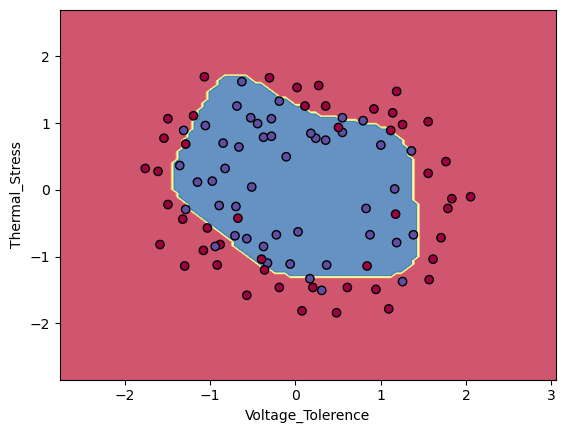

In [25]:
DecisionBoundaryDisplay.from_estimator(
    model,X_train,
    response_method="predict",
    cmap=plt.cm.Spectral,                                  
    alpha=0.8,
    xlabel="Voltage_Tolerence",
    ylabel="Thermal_Stress",)
plt.scatter(X_train[:,0],X_train[:,1],c=y_train,cmap=plt.cm.Spectral,edgecolors='k')
plt.show()

In [26]:
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred,zero_division=0)

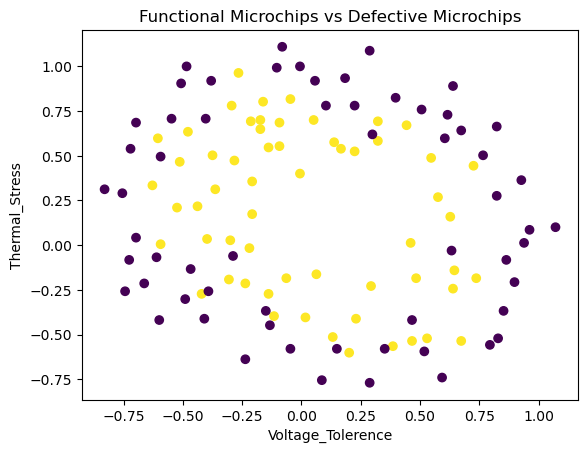

In [27]:

plt.scatter(df["Voltage_Tolerence"],df["Thermal_Stress"],c=df["Failure"])


plt.xlabel("Voltage_Tolerence")
plt.ylabel("Thermal_Stress")
plt.title("Functional Microchips vs Defective Microchips")
plt.show()